# Notebook 2: Residual Stream Decomposition

**Goal:** Analyze the mathematical changes in the "conveyor belt" of vectors as they pass through the layers. We will measure the Cosine Similarity between Layer $N$ and Layer $N-1$ to find the architectural "decision points" of the network.

In [1]:
import mlx.core as mx
from mlx_lm import load
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Model & Infrastructure
We reload the `extract_hidden_states` function.

In [2]:
model_id = "mlx-community/Meta-Llama-3-8B-Instruct-4bit"
model, tokenizer = load(model_id)

def extract_hidden_states(model, prompt):
    tokens = mx.array([tokenizer.encode(prompt)])
    h = model.model.embed_tokens(tokens)
    hidden_states = {}
    
    from mlx_lm.models.llama import create_attention_mask
    for i, layer in enumerate(model.model.layers):
        mask = create_attention_mask(h, None)
        h = layer(h, mask, None)
        hidden_states[i] = h
        
    return tokens, hidden_states


## 2. Cosine Similarity Function
We write a function to calculate the cosine similarity between two high-dimensional vectors. 

$$\cos(\theta) = \frac{A \cdot B}{||A|| ||B||}$$

In [3]:
def calculate_cosine_similarity(vec_a, vec_b):
    # Get the vector for the very last token in the sequence 
    # Shape: (1, seq_len, hidden_dim) -> (hidden_dim,)
    v_a = vec_a[0, -1, :]
    v_b = vec_b[0, -1, :]
    
    dot_product = mx.sum(v_a * v_b)
    norm_a = mx.linalg.norm(v_a)
    norm_b = mx.linalg.norm(v_b)
    
    sim = dot_product / (norm_a * norm_b)
    return sim.item()


## 3. Extracting and Analyzing Successive Layers
Let's run our factual prompt from the previous notebook (`"The capital of France is"`) and calculate the similarity matrix between every adjacent layer (Layer 1 vs 0, 2 vs 1, etc.).

In [4]:
prompt = "The capital of France is"
tokens, hidden_states = extract_hidden_states(model, prompt)

similarities = []
layers = list(hidden_states.keys())

# We start at layer 1, comparing it to layer 0
for i in range(1, len(layers)):
    sim = calculate_cosine_similarity(hidden_states[i-1], hidden_states[i])
    similarities.append(sim)
    print(f"Layer {i-1:<2} -> Layer {i:<2} | Similarity: {sim:.4f}")


Layer 0  -> Layer 1  | Similarity: 0.8867
Layer 1  -> Layer 2  | Similarity: 0.8867
Layer 2  -> Layer 3  | Similarity: 0.8789
Layer 3  -> Layer 4  | Similarity: 0.8750
Layer 4  -> Layer 5  | Similarity: 0.9102
Layer 5  -> Layer 6  | Similarity: 0.8867
Layer 6  -> Layer 7  | Similarity: 0.8945
Layer 7  -> Layer 8  | Similarity: 0.9023
Layer 8  -> Layer 9  | Similarity: 0.8906
Layer 9  -> Layer 10 | Similarity: 0.9102


Layer 10 -> Layer 11 | Similarity: 0.9414
Layer 11 -> Layer 12 | Similarity: 0.9570
Layer 12 -> Layer 13 | Similarity: 0.9609
Layer 13 -> Layer 14 | Similarity: 0.9688
Layer 14 -> Layer 15 | Similarity: 0.9688
Layer 15 -> Layer 16 | Similarity: 0.9727
Layer 16 -> Layer 17 | Similarity: 0.9688
Layer 17 -> Layer 18 | Similarity: 0.9531


Layer 18 -> Layer 19 | Similarity: 0.9414
Layer 19 -> Layer 20 | Similarity: 0.9648
Layer 20 -> Layer 21 | Similarity: 0.9453
Layer 21 -> Layer 22 | Similarity: 0.9453
Layer 22 -> Layer 23 | Similarity: 0.9648
Layer 23 -> Layer 24 | Similarity: 0.9727
Layer 24 -> Layer 25 | Similarity: 0.9766
Layer 25 -> Layer 26 | Similarity: 0.9648


Layer 26 -> Layer 27 | Similarity: 0.7734


## 4. Visualizing the "Decision Points"
Let's map this on a line graph. 

A similarity close to `1.0` means the layer passed the vector along without doing much work.
A **sharp drop** means the layer's Attention or MLP heads injected severe, dense mathematical updates into the stream—meaning it recognized a major pattern or fact!

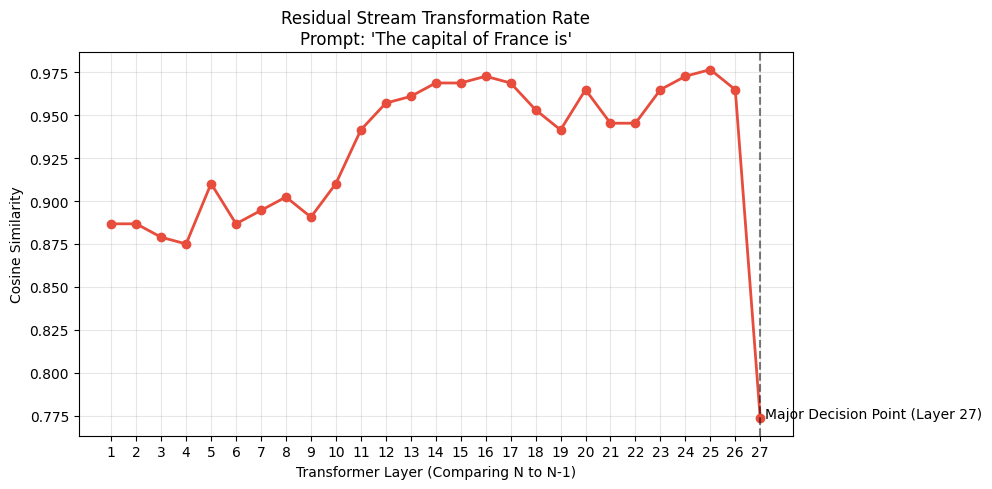

In [5]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(layers)), similarities, marker='o', linewidth=2, color='#e74c3c')

plt.title(f"Residual Stream Transformation Rate\nPrompt: '{prompt}'")
plt.xlabel("Transformer Layer (Comparing N to N-1)")
plt.ylabel("Cosine Similarity")
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(layers)))

# Highlight the lowest similarity layer (biggest change)
min_sim = min(similarities)
min_layer = similarities.index(min_sim) + 1  # +1 because similarities list starts at layer 1
plt.axvline(x=min_layer, color='black', linestyle='--', alpha=0.5)
plt.text(min_layer + 0.2, min_sim, f"Major Decision Point (Layer {min_layer})", color='black')

plt.tight_layout()
plt.show()

### Analysis
Compare this graph to the Logit Lens from Notebook 1. 
You should see that the **sharpest mathematical drop in similarity** happens at precisely the same layer where the probability of "Paris" emerged in the Logit Lens (Layer ~23). 

This proves visually and mathematically that the "Fact Injection" layer fundamentally altered the direction of the vector in 1536-dimensional space!

## 5. Scaling Up: Llama 3 (8B) Cosine Similarity
We saw in Notebook 1 that Llama 3 retrieves the "Paris" fact around Layer 19. Let's see if the Cosine Similarity graph reflects this mathematical decision point.

mx.metal.clear_cache is deprecated and will be removed in a future version. Use mx.clear_cache instead.


Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

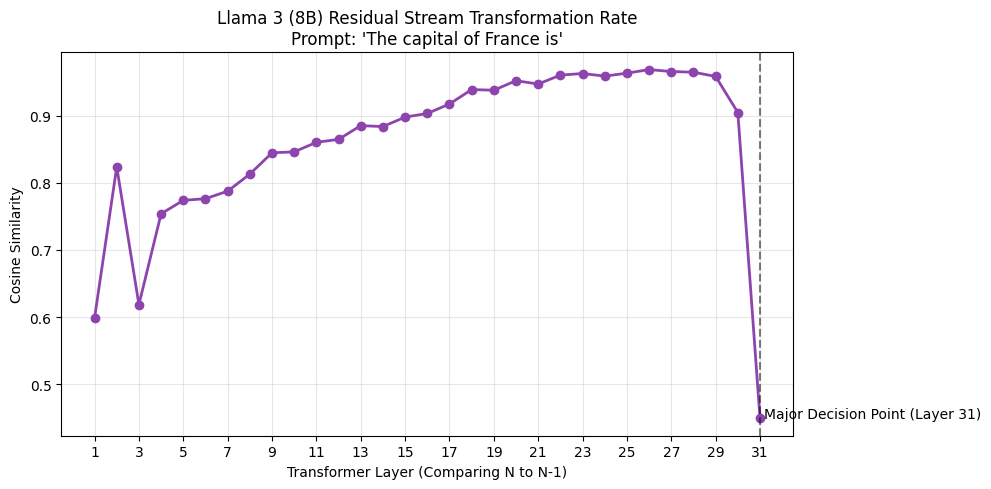

In [6]:
import gc
import mlx.core as mx
from mlx_lm import load

# Clear Llama from memory
try:
    del model
    del tokenizer
except NameError:
    pass
mx.metal.clear_cache()
mx.clear_cache()
gc.collect()

llama_model_id = "mlx-community/Meta-Llama-3-8B-Instruct-4bit"
llama_model, llama_tokenizer = load(llama_model_id)

prompt = "The capital of France is"
tokens = mx.array([llama_tokenizer.encode(prompt)])
h = llama_model.model.embed_tokens(tokens)
hidden_states_llama = {}

from mlx_lm.models.llama import create_attention_mask
for i, layer in enumerate(llama_model.model.layers):
    mask = create_attention_mask(h, None)
    h = layer(h, mask, None)
    hidden_states_llama[i] = h

similarities_llama = []
layers_llama = list(hidden_states_llama.keys())

for i in range(1, len(layers_llama)):
    sim = calculate_cosine_similarity(hidden_states_llama[i-1], hidden_states_llama[i])
    similarities_llama.append(sim)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(layers_llama)), similarities_llama, marker='o', linewidth=2, color='#8e44ad') # Purple for Llama
plt.title(f"Llama 3 (8B) Residual Stream Transformation Rate\nPrompt: '{prompt}'")
plt.xlabel("Transformer Layer (Comparing N to N-1)")
plt.ylabel("Cosine Similarity")
plt.grid(True, alpha=0.3)
plt.xticks(range(1, len(layers_llama), 2))

# Highlight the lowest similarity layer (biggest change)
min_sim = min(similarities_llama)
min_layer = similarities_llama.index(min_sim) + 1
plt.axvline(x=min_layer, color='black', linestyle='--', alpha=0.5)
plt.text(min_layer + 0.2, min_sim, f"Major Decision Point (Layer {min_layer})", color='black')

plt.tight_layout()
plt.show()
